**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**
---
Práctica - Manipulación y Visualización de Datos Económicos y Financieros

## 🎯 Objetivos de Aprendizaje

En este notebook práctico aplicaremos todos los conceptos de la guía completa utilizando datos reales del ámbito económico y financiero:

✅ **Análisis Avanzado con Pandas**: Operaciones de agrupación, pivoteo y merge con datos macroeconómicos  
✅ **Visualización de Datos**: Creación de gráficos económicos especializados  
✅ **Análisis Estadístico**: Análisis descriptivo de indicadores económicos  

## 📊 Dataset: Indicadores Macroeconómicos de Argentina (2020-2024)

Trabajaremos con datos reales que incluyen:
- PIB trimestral
- Inflación mensual
- Tipo de cambio oficial y blue
- Tasa de desempleo
- Riesgo país
- Índice Merval

Estos datos nos permitirán realizar análisis económico empresarial típico del ámbito de FCE-UBA.

In [18]:
# Importaciones estándar para análisis de datos económicos
import numpy as np           # para hacer operaciones matemáticas
import pandas as pd          # para manejo de archivos de datos
import matplotlib.pyplot as plt  # para hacer gráficos
import seaborn as sns        # para hacer gráficos
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ Librerías cargadas correctamente")
print("📊 Configuración de visualización aplicada")

✅ Librerías cargadas correctamente
📊 Configuración de visualización aplicada


## 📈 1. CREACIÓN DE DATASET ECONÓMICO REALISTA

Primero crearemos un dataset con indicadores macroeconómicos de Argentina que simula datos reales del período 2020-2024. Esto nos permitirá trabajar con variables económicas típicas que todo graduado de FCE-UBA debe saber analizar.

In [19]:
# Generación de dataset macroeconómico de Argentina (2020-2024)
np.random.seed(42)  # Para reproducibilidad

# Crear rango de fechas mensuales
fechas = pd.date_range(start='2020-01-01', end='2024-12-31', freq='MS')

# Variables macroeconómicas con tendencias realistas
n_meses = len(fechas)

# PIB trimestral (en billones de pesos, valores realistas)
pib_base = 50  # Billones de pesos base
pib_trend = np.linspace(0, 20, n_meses)  # Crecimiento con inflación
pib_cycle = 5 * np.sin(2 * np.pi * np.arange(n_meses) / 12)  # Ciclo anual
pib_noise = np.random.normal(0, 2, n_meses)
pib_trimestral = pib_base + pib_trend + pib_cycle + pib_noise

# Inflación mensual (% realista para Argentina)
inflacion_base = 5  # 5% mensual base
inflacion_trend = np.linspace(0, 15, n_meses)  # Tendencia creciente
inflacion_noise = np.random.normal(0, 3, n_meses)
inflacion_mensual = np.maximum(0, inflacion_base + inflacion_trend + inflacion_noise)

# Tipo de cambio oficial (pesos por dólar)
tc_base = 80  # Pesos por dólar inicial
tc_trend = np.linspace(0, 800, n_meses)  # Devaluación constante
tc_noise = np.random.normal(0, 20, n_meses)
tipo_cambio_oficial = tc_base + tc_trend + tc_noise

# Tipo de cambio blue (siempre mayor al oficial)
brecha_blue = 1.3 + 0.5 * np.random.random(n_meses)  # Brecha del 30% al 80%
tipo_cambio_blue = tipo_cambio_oficial * brecha_blue

# Desempleo (%)
desempleo_base = 10
desempleo_cycle = 3 * np.sin(2 * np.pi * np.arange(n_meses) / 12 + np.pi/2)  # Ciclo con máximo a mitad de año
desempleo_noise = np.random.normal(0, 1, n_meses)
tasa_desempleo = np.maximum(5, desempleo_base + desempleo_cycle + desempleo_noise)

# Riesgo país (puntos básicos)
riesgo_base = 1500
riesgo_volatility = 300 * np.random.normal(0, 1, n_meses)
riesgo_trend = 200 * np.sin(2 * np.pi * np.arange(n_meses) / 24)  # Ciclo de 2 años
riesgo_pais = np.maximum(800, riesgo_base + riesgo_volatility + riesgo_trend)

# Índice Merval (puntos, con alta volatilidad)
merval_base = 50000
merval_trend = np.linspace(0, 100000, n_meses)  # Tendencia alcista nominal
merval_volatility = 15000 * np.random.normal(0, 1, n_meses)
indice_merval = np.maximum(10000, merval_base + merval_trend + merval_volatility)

# Crear DataFrame principal
df_macro = pd.DataFrame({
    'Fecha': fechas,
    'PIB_Trimestral_Billones': pib_trimestral,
    'Inflacion_Mensual_Pct': inflacion_mensual,
    'TC_Oficial_Pesos_USD': tipo_cambio_oficial,
    'TC_Blue_Pesos_USD': tipo_cambio_blue,
    'Desempleo_Pct': tasa_desempleo,
    'Riesgo_Pais_Puntos': riesgo_pais,
    'Merval_Puntos': indice_merval
})

# Agregar variables derivadas típicas del análisis económico
df_macro['Año'] = df_macro['Fecha'].dt.year
df_macro['Mes'] = df_macro['Fecha'].dt.month
df_macro['Trimestre'] = df_macro['Fecha'].dt.quarter
df_macro['Brecha_Cambiaria_Pct'] = ((df_macro['TC_Blue_Pesos_USD'] - df_macro['TC_Oficial_Pesos_USD']) / df_macro['TC_Oficial_Pesos_USD']) * 100

# Mostrar información del dataset
print("📊 DATASET MACROECONÓMICO DE ARGENTINA (2020-2024)")
print("="*60)
print(f"Período: {df_macro['Fecha'].min().strftime('%Y-%m')} a {df_macro['Fecha'].max().strftime('%Y-%m')}")
print(f"Observaciones: {len(df_macro)} meses")
print(f"Variables: {len(df_macro.columns)} indicadores económicos")
print("\n📈 Primeras 5 observaciones:")
df_macro.head()

📊 DATASET MACROECONÓMICO DE ARGENTINA (2020-2024)
Período: 2020-01 a 2024-12
Observaciones: 60 meses
Variables: 12 indicadores económicos

📈 Primeras 5 observaciones:


,Fecha,PIB_Trimestral_Billones,Inflacion_Mensual_Pct,TC_Oficial_Pesos_USD,TC_Blue_Pesos_USD,Desempleo_Pct,Riesgo_Pais_Puntos,Merval_Puntos,Año,Mes,Trimestre,Brecha_Cambiaria_Pct
0,2020-01-01,50.993428,3.562477,95.820639,133.920985,13.064280,1454.464471,28278.734878,2020,1,1,39.762149
1,2020-02-01,52.562454,4.697260,75.371573,125.209221,11.520331,1728.258971,30582.958639,2020,2,1,66.122606
2,2020-03-01,56.303470,2.189470,135.174530,194.703525,10.784696,1684.297560,42613.167190,2020,3,1,44.038618
3,2020-04-01,59.063009,2.174092,92.640945,121.559555,10.679598,1454.611500,51883.038487,2020,4,2,31.215798
4,2020-05-01,55.217752,8.454527,145.974430,236.877984,7.769633,1610.768406,61443.274501,2020,5,2,62.273615


In [20]:
# Crear dataset complementario: Sectores económicos por trimestre
# Esto nos permitirá practicar operaciones de merge

sectores_data = []
trimestres = df_macro.groupby(['Año', 'Trimestre']).first().reset_index()

for _, row in trimestres.iterrows():
    año = row['Año']
    trimestre = row['Trimestre']
    
    # Simulamos crecimiento sectorial con base en el contexto económico real
    base_growth = -2 if año == 2020 else np.random.normal(1, 3)  # Pandemia en 2020
    
    sectores_data.extend([
        {'Año': año, 'Trimestre': trimestre, 'Sector': 'Agropecuario', 
         'Crecimiento_Pct': base_growth + np.random.normal(2, 1.5),
         'Participacion_PIB': 8.5 + np.random.normal(0, 0.5)},
        {'Año': año, 'Trimestre': trimestre, 'Sector': 'Industria', 
         'Crecimiento_Pct': base_growth + np.random.normal(-1, 2),
         'Participacion_PIB': 25.2 + np.random.normal(0, 1)},
        {'Año': año, 'Trimestre': trimestre, 'Sector': 'Servicios', 
         'Crecimiento_Pct': base_growth + np.random.normal(0.5, 1.5),
         'Participacion_PIB': 58.3 + np.random.normal(0, 0.8)},
        {'Año': año, 'Trimestre': trimestre, 'Sector': 'Construcción', 
         'Crecimiento_Pct': base_growth + np.random.normal(-2, 3),
         'Participacion_PIB': 8.0 + np.random.normal(0, 0.8)}
    ])

df_sectores = pd.DataFrame(sectores_data)

# Dataset adicional: Empresas del Merval para análisis financiero
empresas_merval = ['GGAL', 'YPFD', 'PAM', 'TXAR', 'BMA', 'SUPV', 'MIRG', 'EDN', 'LOMA', 'COME']
meses_sample = df_macro.sample(n=30, random_state=42)['Fecha'].values

empresas_data = []
for fecha in meses_sample:
    for empresa in empresas_merval:
        # Precio de acción simulado
        precio_base = np.random.uniform(50, 500)
        volatilidad = np.random.normal(0, precio_base * 0.1)
        precio = max(10, precio_base + volatilidad)
        
        # Volumen de operaciones
        volumen = np.random.randint(100000, 5000000)
        
        # ROE simulado
        roe = np.random.normal(8, 15)  # ROE típico empresas argentinas
        
        empresas_data.append({
            'Fecha': fecha,
            'Empresa': empresa,
            'Precio_Accion': precio,
            'Volumen_Operaciones': volumen,
            'ROE_Pct': roe,
            'Sector_Empresa': np.random.choice(['Financiero', 'Energía', 'Consumo', 'Telecomunicaciones'])
        })

df_empresas = pd.DataFrame(empresas_data)

print("✅ Datasets complementarios creados:")
print(f"📊 Sectores económicos: {len(df_sectores)} observaciones")
print(f"🏢 Empresas Merval: {len(df_empresas)} observaciones")
print(f"📈 Variables sectoriales: {df_sectores['Sector'].nunique()} sectores")
print(f"💼 Empresas analizadas: {df_empresas['Empresa'].nunique()} compañías")

df_sectores.head(8)

✅ Datasets complementarios creados:
📊 Sectores económicos: 80 observaciones
🏢 Empresas Merval: 300 observaciones
📈 Variables sectoriales: 4 sectores
💼 Empresas analizadas: 10 compañías

📊 Sectores económicos: 80 observaciones
🏢 Empresas Merval: 300 observaciones
📈 Variables sectoriales: 4 sectores
💼 Empresas analizadas: 10 compañías


,Año,Trimestre,Sector,Crecimiento_Pct,Participacion_PIB
0,2020,1,Agropecuario,-1.601431,8.428810
1,2020,1,Industria,-2.759409,25.714439
2,2020,1,Servicios,-0.432578,57.400286
3,2020,1,Construcción,-8.602343,9.022141
4,2020,2,Agropecuario,0.498471,8.125757
5,2020,2,Industria,0.102304,25.315675
6,2020,2,Servicios,0.268946,58.354015
7,2020,2,Construcción,2.182244,9.404273


## 📊 2. ANÁLISIS AVANZADO CON PANDAS

Aplicaremos las técnicas avanzadas de la guía a nuestros datos macroeconómicos. Comenzaremos con operaciones de agrupación para analizar tendencias por período.

In [21]:
# 🔍 2.1 OPERACIONES DE AGRUPACIÓN (GROUPBY) - ANÁLISIS ANUAL

print("📈 ANÁLISIS MACROECONÓMICO POR AÑO")
print("="*50)

# Agrupación por año con múltiples estadísticos
analisis_anual = df_macro.groupby('Año').agg({
    'Inflacion_Mensual_Pct': ['mean', 'sum', 'std'],
    'TC_Oficial_Pesos_USD': ['mean', 'min', 'max'],
    'Desempleo_Pct': 'mean',
    'Riesgo_Pais_Puntos': 'mean',
    'Brecha_Cambiaria_Pct': 'mean',
    'PIB_Trimestral_Billones': 'mean'
}).round(2)

# Aplanar nombres de columnas
analisis_anual.columns = ['_'.join(col).strip() for col in analisis_anual.columns]

print("🔸 INDICADORES ECONÓMICOS ANUALES:")
print("\n📊 Variables clave por año:")
analisis_anual_display = analisis_anual[['Inflacion_Mensual_Pct_mean', 'Inflacion_Mensual_Pct_sum', 
                                        'TC_Oficial_Pesos_USD_mean', 'Desempleo_Pct_mean', 
                                        'Brecha_Cambiaria_Pct_mean']]
analisis_anual_display.columns = ['Inflación_Prom_Mes (%)', 'Inflación_Anual (%)', 
                                  'TC_Oficial_Prom', 'Desempleo_Prom (%)', 'Brecha_Cambiaria (%)']

print(analisis_anual_display)

# Análisis por trimestre para identificar estacionalidad
print(f"\n📈 ANÁLISIS POR TRIMESTRE (Estacionalidad)")
print("="*50)

estacionalidad = df_macro.groupby('Trimestre').agg({
    'Inflacion_Mensual_Pct': 'mean',
    'Desempleo_Pct': 'mean',
    'PIB_Trimestral_Billones': 'mean'
}).round(2)

estacionalidad.columns = ['Inflación_Promedio (%)', 'Desempleo_Promedio (%)', 'PIB_Promedio (Bill)']
print(estacionalidad)

📈 ANÁLISIS MACROECONÓMICO POR AÑO
🔸 INDICADORES ECONÓMICOS ANUALES:

📊 Variables clave por año:
      Inflación_Prom_Mes (%)  Inflación_Anual (%)  TC_Oficial_Prom  Desempleo_Prom (%)  Brecha_Cambiaria (%)
Año                                                                                                         
2020                    6.84                82.03           153.27                9.90                 55.70
2021                    9.13               109.55           315.01               10.01                 60.91
2022                   12.02               144.29           478.39               10.13                 57.51
2023                   15.46               185.56           652.80                9.61                 65.78
2024                   18.99               227.91           809.73               10.01                 47.58

📈 ANÁLISIS POR TRIMESTRE (Estacionalidad)
           Inflación_Promedio (%)  Desempleo_Promedio (%)  PIB_Promedio (Bill)
Trimestre          

In [22]:
# 🔄 2.2 PIVOTEO Y RESHAPE - TABLA DE INDICADORES ECONÓMICOS

print("🔄 ANÁLISIS MEDIANTE PIVOT TABLES")
print("="*50)

# Crear tabla pivot para análisis de inflación por año y trimestre
pivot_inflacion = df_macro.pivot_table(
    values='Inflacion_Mensual_Pct',
    index='Año',
    columns='Trimestre',
    aggfunc='mean'
).round(2)

print("📊 INFLACIÓN PROMEDIO POR AÑO Y TRIMESTRE:")
print("(Valores en % mensual)")
pivot_inflacion.columns = [f'Q{col}' for col in pivot_inflacion.columns]
print(pivot_inflacion)

# Pivot para tipo de cambio
pivot_tc = df_macro.pivot_table(
    values=['TC_Oficial_Pesos_USD', 'TC_Blue_Pesos_USD'],
    index='Año',
    columns='Trimestre',
    aggfunc='mean'
).round(0)

print(f"\n💵 TIPO DE CAMBIO PROMEDIO POR TRIMESTRE:")
print("(Valores en Pesos por USD)")
print(pivot_tc.head())

# Melt para convertir de wide a long format (útil para visualizaciones)
df_tc_long = df_macro.melt(
    id_vars=['Fecha', 'Año', 'Mes'],
    value_vars=['TC_Oficial_Pesos_USD', 'TC_Blue_Pesos_USD'],
    var_name='Tipo_Cambio',
    value_name='Valor_Pesos_USD'
)

print(f"\n🔄 CONVERSIÓN A FORMATO LONG PARA ANÁLISIS:")
print(f"Dimensiones originales: {df_macro.shape}")
print(f"Dimensiones formato long: {df_tc_long.shape}")
print("\n📈 Muestra del dataset en formato long:")
df_tc_long.head(6)

🔄 ANÁLISIS MEDIANTE PIVOT TABLES
📊 INFLACIÓN PROMEDIO POR AÑO Y TRIMESTRE:
(Valores en % mensual)
         Q1     Q2     Q3     Q4
Año                             
2020   3.48   6.99   8.07   8.80
2021   7.21   9.68   7.72  11.91
2022  10.96  12.43  13.25  11.46
2023  14.97  13.10  14.63  19.16
2024  15.72  20.72  19.06  20.47

💵 TIPO DE CAMBIO PROMEDIO POR TRIMESTRE:
(Valores en Pesos por USD)
          TC_Blue_Pesos_USD                         TC_Oficial_Pesos_USD                     
Trimestre                 1       2       3       4                    1      2      3      4
Año                                                                                          
2020                  151.0   208.0   292.0   311.0                102.0  143.0  165.0  202.0
2021                  419.0   468.0   512.0   627.0                246.0  300.0  336.0  378.0
2022                  631.0   715.0   842.0   823.0                418.0  456.0  500.0  540.0
2023                 1010.0  1014.0  1

,Fecha,Año,Mes,Tipo_Cambio,Valor_Pesos_USD
0,2020-01-01,2020,1,TC_Oficial_Pesos_USD,95.820639
1,2020-02-01,2020,2,TC_Oficial_Pesos_USD,75.371573
2,2020-03-01,2020,3,TC_Oficial_Pesos_USD,135.174530
3,2020-04-01,2020,4,TC_Oficial_Pesos_USD,92.640945
4,2020-05-01,2020,5,TC_Oficial_Pesos_USD,145.974430
5,2020-06-01,2020,6,TC_Oficial_Pesos_USD,191.605723


In [23]:
# 🔗 2.3 MERGE Y JOIN - INTEGRACIÓN DE DATOS MACROECONÓMICOS Y SECTORIALES

print("🔗 INTEGRACIÓN DE DATOS MEDIANTE MERGE")
print("="*50)

# Preparar datos macro para merge (agregación trimestral)
df_macro_trimestral = df_macro.groupby(['Año', 'Trimestre']).agg({
    'PIB_Trimestral_Billones': 'mean',
    'Inflacion_Mensual_Pct': 'mean',
    'TC_Oficial_Pesos_USD': 'mean',
    'Desempleo_Pct': 'mean',
    'Riesgo_Pais_Puntos': 'mean'
}).round(2).reset_index()

# INNER JOIN: Solo trimestres presentes en ambos datasets
datos_integrados = pd.merge(
    df_macro_trimestral,
    df_sectores,
    on=['Año', 'Trimestre'],
    how='inner'
)

print(f"✅ INNER JOIN completado:")
print(f"📊 Observaciones macro: {len(df_macro_trimestral)}")
print(f"📈 Observaciones sectoriales: {len(df_sectores)}")
print(f"🔗 Observaciones integradas: {len(datos_integrados)}")

# Análisis del dataset integrado
print(f"\n📊 ANÁLISIS DE DATOS INTEGRADOS:")
print(f"Sectores económicos: {datos_integrados['Sector'].unique()}")
print(f"Período analizado: {datos_integrados['Año'].min()}-{datos_integrados['Año'].max()}")

# Ejemplo de análisis integrado: Relación PIB-Sectores
analisis_pib_sectores = datos_integrados.groupby('Sector').agg({
    'PIB_Trimestral_Billones': 'mean',
    'Crecimiento_Pct': 'mean',
    'Participacion_PIB': 'mean',
    'Inflacion_Mensual_Pct': 'mean'
}).round(2)

analisis_pib_sectores.columns = ['PIB_Promedio', 'Crecimiento_Sectorial (%)', 
                                'Participación_PIB (%)', 'Inflación_Período (%)']
print(f"\n📈 PERFORMANCE SECTORIAL:")
print(analisis_pib_sectores.sort_values('Crecimiento_Sectorial (%)', ascending=False))

# LEFT JOIN con empresas para análisis financiero
empresas_con_macro = pd.merge(
    df_empresas,
    df_macro[['Fecha', 'TC_Oficial_Pesos_USD', 'Riesgo_Pais_Puntos', 'Merval_Puntos']],
    on='Fecha',
    how='left'
)

print(f"\n💼 ANÁLISIS EMPRESARIAL CON CONTEXTO MACRO:")
print(f"Empresas con contexto macro: {len(empresas_con_macro)}")
print(f"Variables financieras integradas: {empresas_con_macro.shape[1]}")

empresas_con_macro.head(3)

🔗 INTEGRACIÓN DE DATOS MEDIANTE MERGE
✅ INNER JOIN completado:
📊 Observaciones macro: 20
📈 Observaciones sectoriales: 80
🔗 Observaciones integradas: 80

📊 ANÁLISIS DE DATOS INTEGRADOS:
Sectores económicos: ['Agropecuario' 'Industria' 'Servicios' 'Construcción']
Período analizado: 2020-2024

📈 PERFORMANCE SECTORIAL:
              PIB_Promedio  Crecimiento_Sectorial (%)  Participación_PIB (%)  Inflación_Período (%)
Sector                                                                                             
Agropecuario         59.69                       2.21                   8.37                  12.49
Servicios            59.69                       1.39                  58.25                  12.49
Industria            59.69                      -0.52                  25.24                  12.49
Construcción         59.69                      -1.48                   7.96                  12.49

💼 ANÁLISIS EMPRESARIAL CON CONTEXTO MACRO:
Empresas con contexto macro: 300
Variab

,Fecha,Empresa,Precio_Accion,Volumen_Operaciones,ROE_Pct,Sector_Empresa,TC_Oficial_Pesos_USD,Riesgo_Pais_Puntos,Merval_Puntos
0,2020-01-01,GGAL,360.814737,2032728,9.230823,Financiero,95.820639,1454.464471,28278.734878
1,2020-01-01,YPFD,349.849779,3277993,13.817673,Financiero,95.820639,1454.464471,28278.734878
2,2020-01-01,PAM,490.667808,3317635,0.349754,Financiero,95.820639,1454.464471,28278.734878


## 📊 3. VISUALIZACIÓN DE DATOS ECONÓMICOS

Ahora aplicaremos las técnicas de visualización de la guía para crear gráficos especializados en análisis económico y financiero.

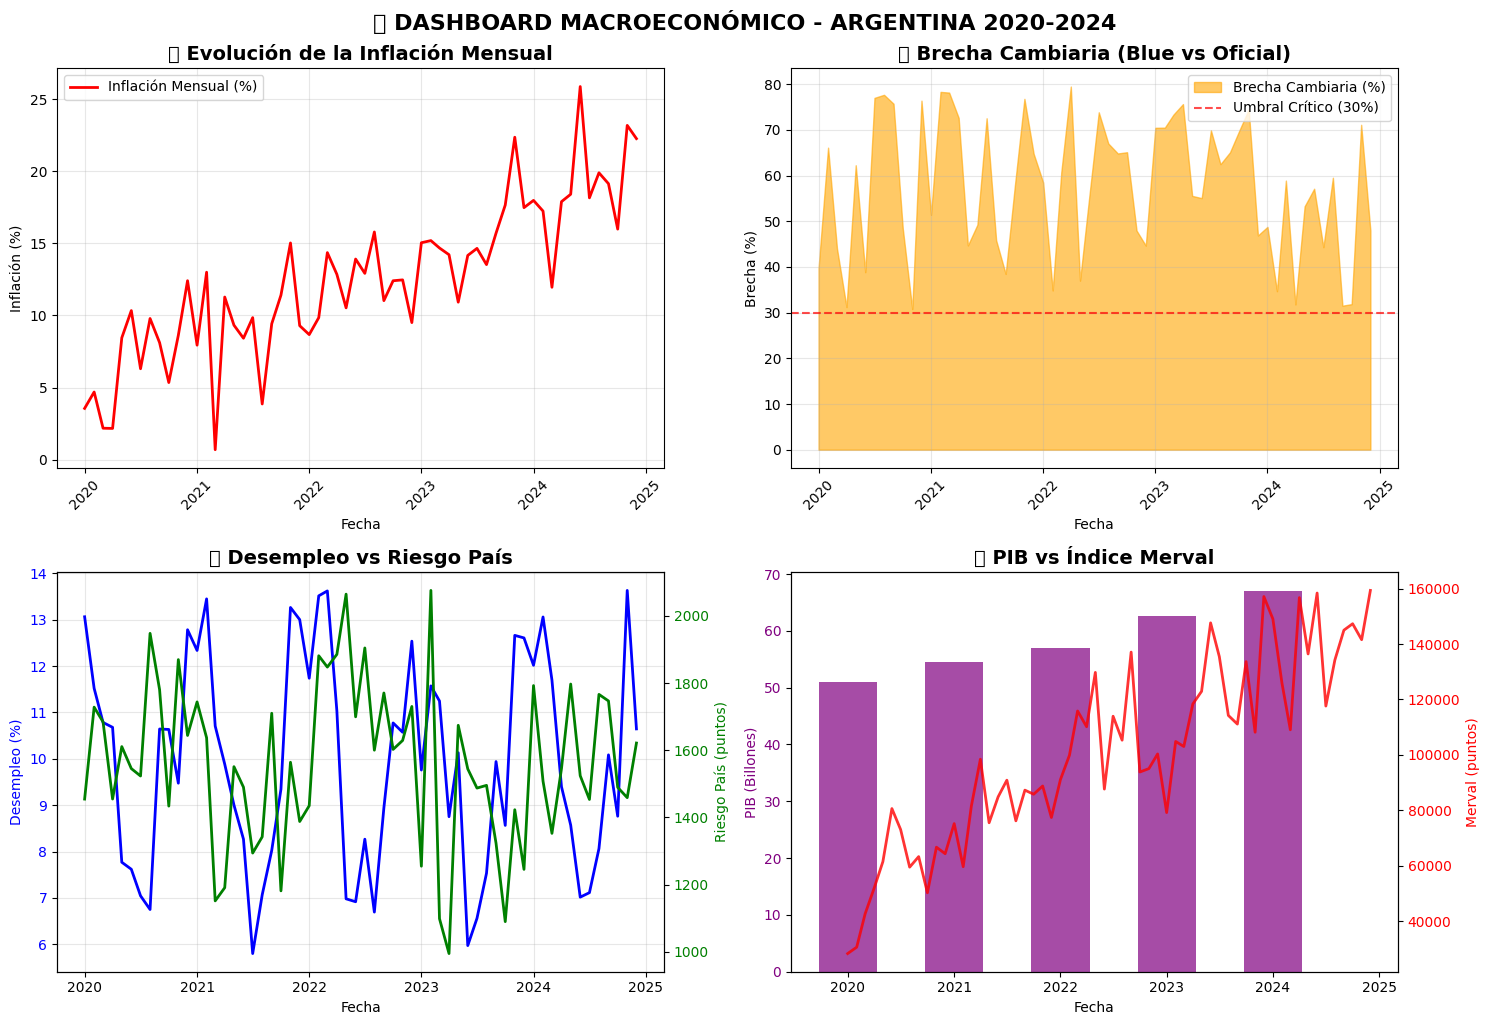

✅ Dashboard macroeconómico generado
📈 Gráficos: Inflación, Brecha Cambiaria, Desempleo vs Riesgo País, PIB vs Merval


In [24]:
# 📈 3.1 GRÁFICOS ECONÓMICOS ESPECIALIZADOS CON MATPLOTLIB

# Gráfico 1: Evolución temporal de indicadores clave
plt.figure(figsize=(15, 10))

# Subplot 1: Inflación y Tipo de Cambio
plt.subplot(2, 2, 1)
plt.plot(df_macro['Fecha'], df_macro['Inflacion_Mensual_Pct'], 'red', linewidth=2, label='Inflación Mensual (%)')
plt.title('📊 Evolución de la Inflación Mensual', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Inflación (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)

# Subplot 2: Brecha Cambiaria
plt.subplot(2, 2, 2)
plt.fill_between(df_macro['Fecha'], df_macro['Brecha_Cambiaria_Pct'], 
                 alpha=0.6, color='orange', label='Brecha Cambiaria (%)')
plt.axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Umbral Crítico (30%)')
plt.title('💵 Brecha Cambiaria (Blue vs Oficial)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Brecha (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)

# Subplot 3: Desempleo y Riesgo País
plt.subplot(2, 2, 3)
ax1 = plt.gca()
line1 = ax1.plot(df_macro['Fecha'], df_macro['Desempleo_Pct'], 'blue', linewidth=2, label='Desempleo (%)')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Desempleo (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
line2 = ax2.plot(df_macro['Fecha'], df_macro['Riesgo_Pais_Puntos'], 'green', linewidth=2, label='Riesgo País')
ax2.set_ylabel('Riesgo País (puntos)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('📊 Desempleo vs Riesgo País', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Subplot 4: PIB e Índice Merval
plt.subplot(2, 2, 4)
ax3 = plt.gca()
line3 = ax3.bar(df_macro['Fecha'][::12], df_macro['PIB_Trimestral_Billones'][::12], 
                alpha=0.7, color='purple', label='PIB (Billones)', width=200)
ax3.set_xlabel('Fecha')
ax3.set_ylabel('PIB (Billones)', color='purple')
ax3.tick_params(axis='y', labelcolor='purple')

ax4 = ax3.twinx()
line4 = ax4.plot(df_macro['Fecha'], df_macro['Merval_Puntos'], 'red', 
                 linewidth=2, alpha=0.8, label='Índice Merval')
ax4.set_ylabel('Merval (puntos)', color='red')
ax4.tick_params(axis='y', labelcolor='red')

plt.title('💰 PIB vs Índice Merval', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle('📊 DASHBOARD MACROECONÓMICO - ARGENTINA 2020-2024', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("✅ Dashboard macroeconómico generado")
print("📈 Gráficos: Inflación, Brecha Cambiaria, Desempleo vs Riesgo País, PIB vs Merval")

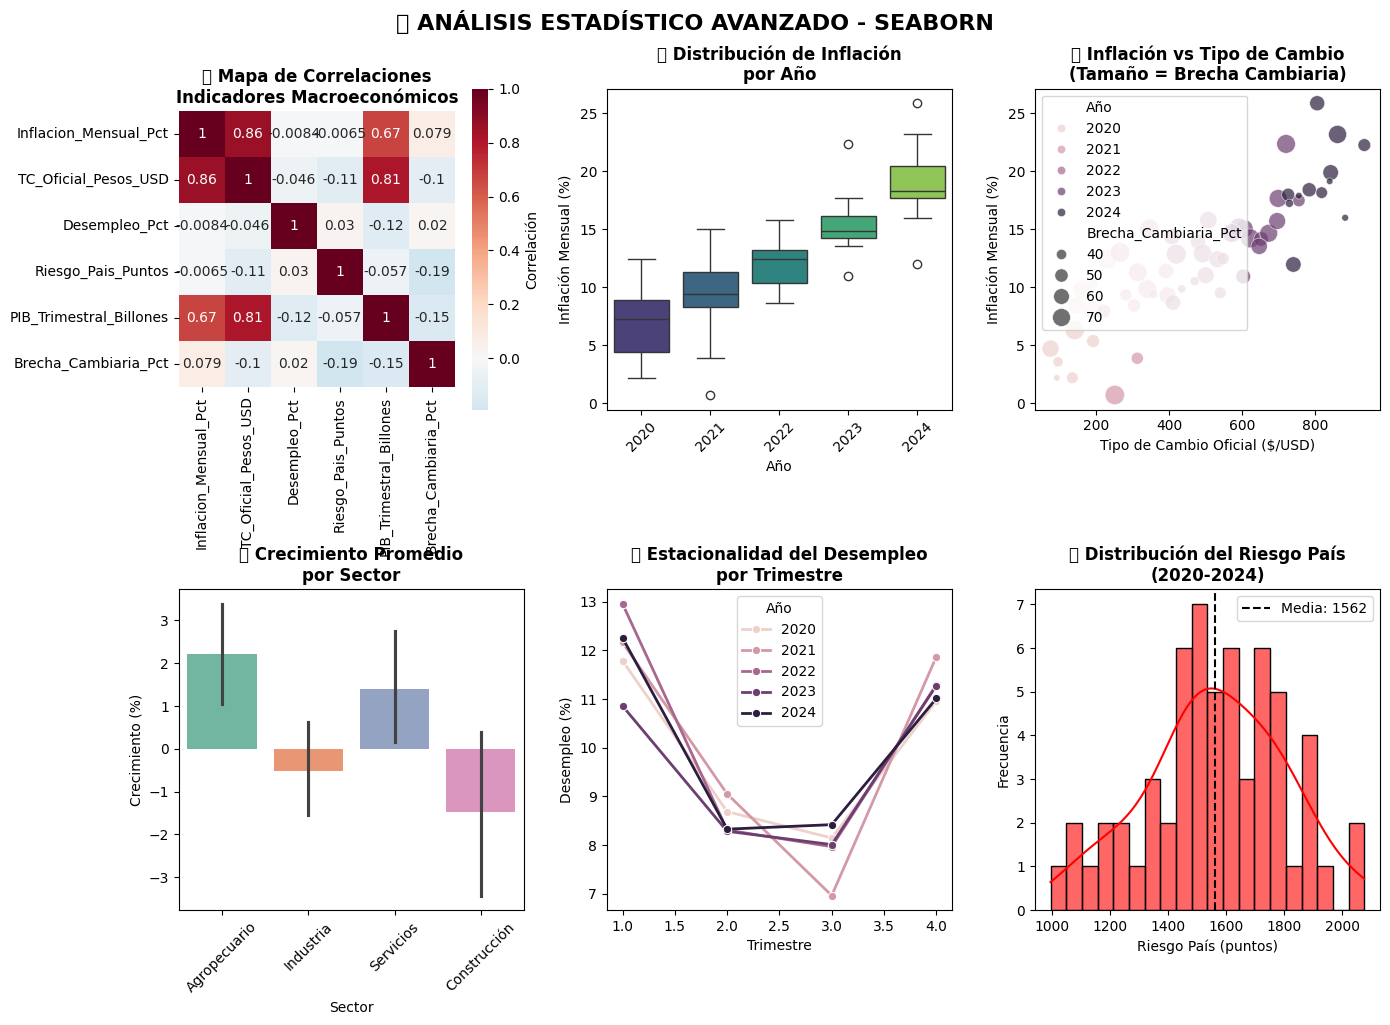

✅ Análisis estadístico con Seaborn completado
🎨 Gráficos: Correlaciones, Boxplots, Scatterplots, Barplots, Líneas temporales, Histogramas


In [25]:
# 🎨 3.2 VISUALIZACIONES ESTADÍSTICAS CON SEABORN

# Preparar datos para análisis de correlaciones
variables_macro = ['Inflacion_Mensual_Pct', 'TC_Oficial_Pesos_USD', 'Desempleo_Pct', 
                  'Riesgo_Pais_Puntos', 'PIB_Trimestral_Billones', 'Brecha_Cambiaria_Pct']

plt.figure(figsize=(14, 10))

# Subplot 1: Mapa de calor de correlaciones
plt.subplot(2, 3, 1)
correlaciones = df_macro[variables_macro].corr()
sns.heatmap(correlaciones, annot=True, cmap='RdBu_r', center=0, 
            square=True, cbar_kws={'label': 'Correlación'})
plt.title('🔥 Mapa de Correlaciones\nIndicadores Macroeconómicos', fontweight='bold')

# Subplot 2: Distribución de la inflación por año
plt.subplot(2, 3, 2)
sns.boxplot(data=df_macro, x='Año', y='Inflacion_Mensual_Pct', palette='viridis')
plt.title('📊 Distribución de Inflación\npor Año', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Inflación Mensual (%)')

# Subplot 3: Relación Inflación vs Tipo de Cambio
plt.subplot(2, 3, 3)
sns.scatterplot(data=df_macro, x='TC_Oficial_Pesos_USD', y='Inflacion_Mensual_Pct', 
                hue='Año', size='Brecha_Cambiaria_Pct', sizes=(20, 200), alpha=0.7)
plt.title('💵 Inflación vs Tipo de Cambio\n(Tamaño = Brecha Cambiaria)', fontweight='bold')
plt.xlabel('Tipo de Cambio Oficial ($/USD)')
plt.ylabel('Inflación Mensual (%)')

# Subplot 4: Performance sectorial
plt.subplot(2, 3, 4)
sns.barplot(data=datos_integrados, x='Sector', y='Crecimiento_Pct', 
            estimator='mean', palette='Set2')
plt.title('📈 Crecimiento Promedio\npor Sector', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Crecimiento (%)')

# Subplot 5: Análisis temporal del desempleo
plt.subplot(2, 3, 5)
df_desempleo_trim = df_macro.groupby(['Año', 'Trimestre'])['Desempleo_Pct'].mean().reset_index()
sns.lineplot(data=df_desempleo_trim, x='Trimestre', y='Desempleo_Pct', 
             hue='Año', marker='o', linewidth=2)
plt.title('📊 Estacionalidad del Desempleo\npor Trimestre', fontweight='bold')
plt.ylabel('Desempleo (%)')

# Subplot 6: Distribución del riesgo país
plt.subplot(2, 3, 6)
sns.histplot(data=df_macro, x='Riesgo_Pais_Puntos', kde=True, 
             color='red', alpha=0.6, bins=20)
plt.axvline(df_macro['Riesgo_Pais_Puntos'].mean(), color='black', 
            linestyle='--', label=f'Media: {df_macro["Riesgo_Pais_Puntos"].mean():.0f}')
plt.title('🌍 Distribución del Riesgo País\n(2020-2024)', fontweight='bold')
plt.xlabel('Riesgo País (puntos)')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.suptitle('🎨 ANÁLISIS ESTADÍSTICO AVANZADO - SEABORN', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("✅ Análisis estadístico con Seaborn completado")
print("🎨 Gráficos: Correlaciones, Boxplots, Scatterplots, Barplots, Líneas temporales, Histogramas")

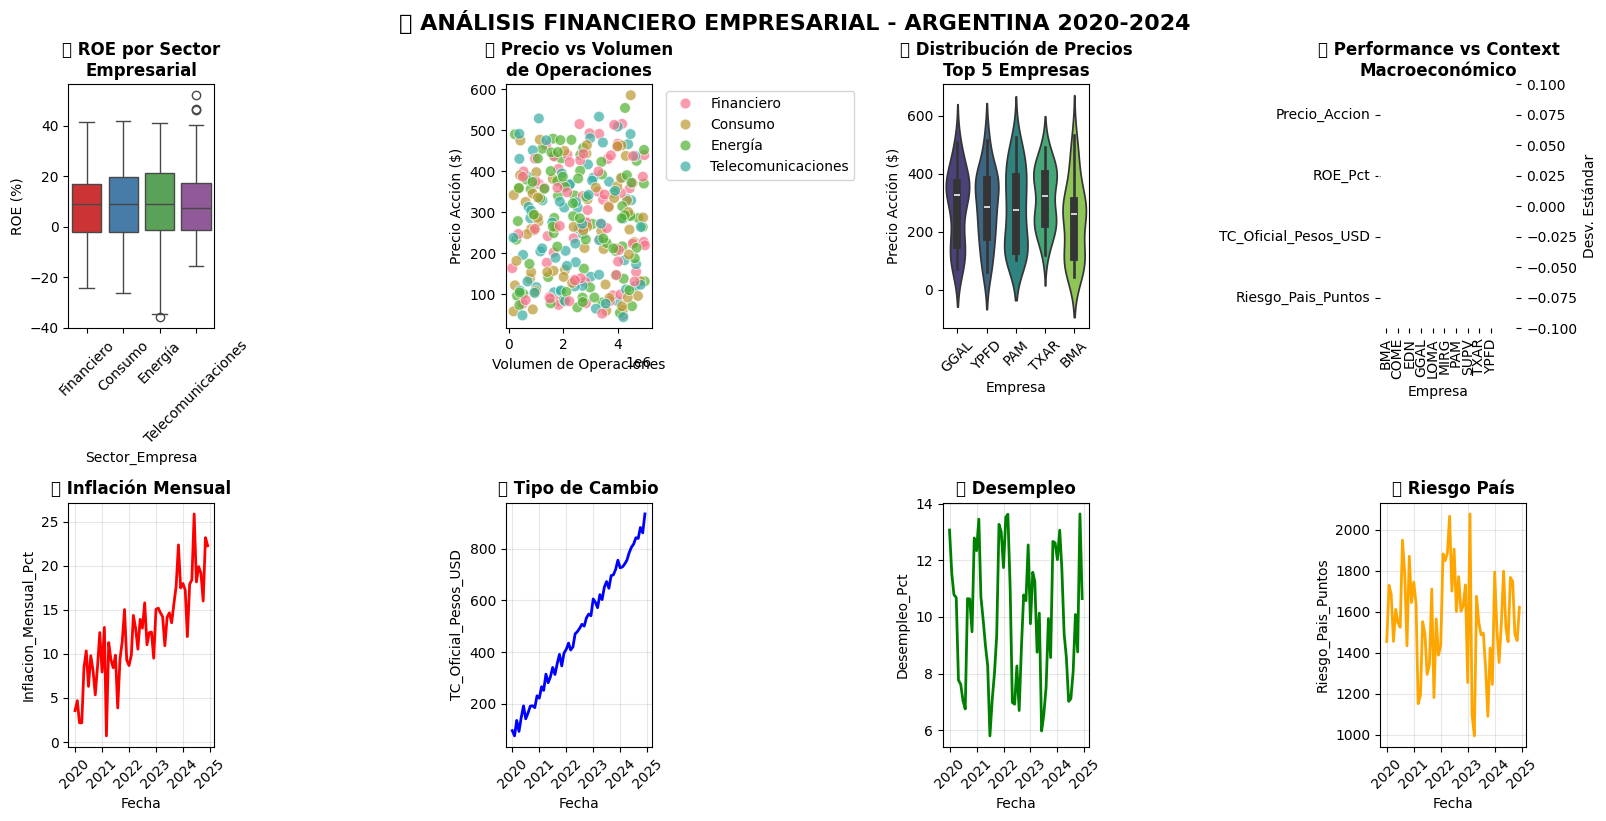

✅ Análisis financiero empresarial completado
💼 Incluye: ROE sectorial, relaciones precio-volumen, distribuciones y contexto macroeconómico


In [26]:
# 💼 3.3 ANÁLISIS FINANCIERO EMPRESARIAL - SEABORN AVANZADO

plt.figure(figsize=(16, 8))

# Subplot 1: Performance empresarial por sector
plt.subplot(2, 4, 1)
sns.boxplot(data=empresas_con_macro, x='Sector_Empresa', y='ROE_Pct', palette='Set1')
plt.title('💰 ROE por Sector\nEmpresarial', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('ROE (%)')

# Subplot 2: Relación precio vs volumen
plt.subplot(2, 4, 2)
sns.scatterplot(data=empresas_con_macro, x='Volumen_Operaciones', y='Precio_Accion', 
                hue='Sector_Empresa', alpha=0.7, s=60)
plt.title('📊 Precio vs Volumen\nde Operaciones', fontweight='bold')
plt.xlabel('Volumen de Operaciones')
plt.ylabel('Precio Acción ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Subplot 3: Violin plot de precios por empresa
plt.subplot(2, 4, 3)
top_empresas = empresas_con_macro['Empresa'].value_counts().head(5).index
empresas_top = empresas_con_macro[empresas_con_macro['Empresa'].isin(top_empresas)]
sns.violinplot(data=empresas_top, x='Empresa', y='Precio_Accion', palette='viridis')
plt.title('🎻 Distribución de Precios\nTop 5 Empresas', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Precio Acción ($)')

# Subplot 4: Heatmap de empresas vs contexto macro
plt.subplot(2, 4, 4)
empresa_macro = empresas_con_macro.groupby('Empresa')[['Precio_Accion', 'ROE_Pct', 
                                                       'TC_Oficial_Pesos_USD', 'Riesgo_Pais_Puntos']].mean()
empresa_macro_norm = (empresa_macro - empresa_macro.mean()) / empresa_macro.std()
sns.heatmap(empresa_macro_norm.T, annot=True, cmap='RdYlBu_r', center=0, 
            cbar_kws={'label': 'Desv. Estándar'})
plt.title('🔥 Performance vs Context\nMacroeconómico', fontweight='bold')

# Subplot 5-8: Series temporales de indicadores clave
indicadores = ['Inflacion_Mensual_Pct', 'TC_Oficial_Pesos_USD', 'Desempleo_Pct', 'Riesgo_Pais_Puntos']
titulos = ['📈 Inflación Mensual', '💵 Tipo de Cambio', '👥 Desempleo', '🌍 Riesgo País']
colores = ['red', 'blue', 'green', 'orange']

for i, (indicador, titulo, color) in enumerate(zip(indicadores, titulos, colores)):
    plt.subplot(2, 4, 5+i)
    sns.lineplot(data=df_macro, x='Fecha', y=indicador, color=color, linewidth=2)
    plt.title(titulo, fontweight='bold')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('💼 ANÁLISIS FINANCIERO EMPRESARIAL - ARGENTINA 2020-2024', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("✅ Análisis financiero empresarial completado")
print("💼 Incluye: ROE sectorial, relaciones precio-volumen, distribuciones y contexto macroeconómico")

## 🔢 4. ANÁLISIS ESTADÍSTICO DESCRIPTIVO

Aplicaremos las técnicas estadísticas de la guía para realizar un análisis descriptivo completo de nuestros indicadores macroeconómicos.

In [27]:
# 📊 4.1 MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN

print("📊 ANÁLISIS ESTADÍSTICO DESCRIPTIVO COMPLETO")
print("="*60)

# Seleccionar variables clave para análisis
variables_analisis = ['Inflacion_Mensual_Pct', 'TC_Oficial_Pesos_USD', 'Desempleo_Pct', 
                     'Riesgo_Pais_Puntos', 'PIB_Trimestral_Billones', 'Brecha_Cambiaria_Pct']

# Estadísticas descriptivas completas
estadisticas = df_macro[variables_analisis].describe().round(2)

print("📈 ESTADÍSTICAS DESCRIPTIVAS - INDICADORES MACROECONÓMICOS")
print("-" * 60)

# Agregar medidas adicionales
medidas_adicionales = pd.DataFrame({
    'Mediana': df_macro[variables_analisis].median(),
    'Moda': df_macro[variables_analisis].mode().iloc[0] if len(df_macro[variables_analisis].mode()) > 0 else np.nan,
    'Rango': df_macro[variables_analisis].max() - df_macro[variables_analisis].min(),
    'Coef_Variacion': (df_macro[variables_analisis].std() / df_macro[variables_analisis].mean()) * 100,
    'Asimetría': df_macro[variables_analisis].skew(),
    'Curtosis': df_macro[variables_analisis].kurtosis()
}).round(2)

# Combinar estadísticas
estadisticas_completas = pd.concat([estadisticas.T, medidas_adicionales], axis=1)

print(estadisticas_completas)

print(f"\n💡 INTERPRETACIÓN ECONÓMICA:")
print("="*50)

# Análisis específico por variable
for var in variables_analisis:
    media = df_macro[var].mean()
    desv_std = df_macro[var].std()
    cv = (desv_std / media) * 100
    
    print(f"\n📌 {var}:")
    print(f"   • Media: {media:.2f}")
    print(f"   • Desviación estándar: {desv_std:.2f}")
    print(f"   • Coeficiente de variación: {cv:.1f}%")
    
    if cv > 50:
        print(f"   🔍 ALTA VOLATILIDAD - Variable muy inestable")
    elif cv > 20:
        print(f"   ⚠️  VOLATILIDAD MODERADA - Variabilidad significativa")
    else:
        print(f"   ✅ BAJA VOLATILIDAD - Variable relativamente estable")

📊 ANÁLISIS ESTADÍSTICO DESCRIPTIVO COMPLETO
📈 ESTADÍSTICAS DESCRIPTIVAS - INDICADORES MACROECONÓMICOS
------------------------------------------------------------
                         count     mean     std     min      25%      50%      75%      max  Mediana    Moda    Rango  Coef_Variacion  Asimetría  Curtosis
Inflacion_Mensual_Pct     60.0    12.49    5.36    0.70     9.32    12.44    15.72    25.86    12.44    0.70    25.16           42.90       0.07      0.00
TC_Oficial_Pesos_USD      60.0   481.84  241.40   75.37   277.40   485.47   696.51   934.40   485.47   75.37   859.03           50.10       0.03     -1.17
Desempleo_Pct             60.0     9.93    2.27    5.80     8.05    10.01    11.71    13.63    10.01    5.80     7.83           22.88      -0.01     -1.15
Riesgo_Pais_Puntos        60.0  1562.14  240.39  994.32  1434.41  1548.13  1733.70  2075.95  1548.13  994.32  1081.63           15.39      -0.17     -0.20
PIB_Trimestral_Billones   60.0    59.69    6.57   47.44    54.

In [28]:
# 🔗 4.2 ANÁLISIS DE CORRELACIONES ECONÓMICAS

print("🔗 ANÁLISIS DE CORRELACIONES MACROECONÓMICAS")
print("="*55)

# Matriz de correlaciones
matriz_correlaciones = df_macro[variables_analisis].corr()

print("📊 MATRIZ DE CORRELACIONES:")
print(matriz_correlaciones.round(3))

# Identificar correlaciones significativas (|r| > 0.5)
correlaciones_fuertes = []
for i in range(len(matriz_correlaciones.columns)):
    for j in range(i+1, len(matriz_correlaciones.columns)):
        var1 = matriz_correlaciones.columns[i]
        var2 = matriz_correlaciones.columns[j]
        corr_valor = matriz_correlaciones.iloc[i, j]
        
        if abs(corr_valor) > 0.5:
            correlaciones_fuertes.append({
                'Variable_1': var1,
                'Variable_2': var2,
                'Correlación': corr_valor,
                'Tipo': 'Positiva fuerte' if corr_valor > 0.5 else 'Negativa fuerte'
            })

df_corr_fuertes = pd.DataFrame(correlaciones_fuertes)

print(f"\n🎯 CORRELACIONES SIGNIFICATIVAS (|r| > 0.5):")
print("-" * 55)
if len(df_corr_fuertes) > 0:
    for _, row in df_corr_fuertes.iterrows():
        print(f"📌 {row['Variable_1']} ↔ {row['Variable_2']}")
        print(f"   • Correlación: {row['Correlación']:.3f} ({row['Tipo']})")
        
        # Interpretación económica específica
        if 'TC_' in row['Variable_1'] and 'Inflacion' in row['Variable_2']:
            print(f"   💡 Relación devaluación-inflación típica de economías emergentes")
        elif 'Desempleo' in row['Variable_1'] and 'PIB' in row['Variable_2']:
            print(f"   💡 Ley de Okun: relación inversa entre desempleo y crecimiento")
        elif 'Riesgo' in row['Variable_1']:
            print(f"   💡 Riesgo país refleja percepción externa de estabilidad económica")
        print()
else:
    print("No se encontraron correlaciones significativas")

# Análisis de percentiles para identificar valores extremos
print(f"\n📊 ANÁLISIS DE PERCENTILES (Identificación de valores extremos):")
print("-" * 55)

percentiles = [10, 25, 50, 75, 90]
analisis_percentiles = df_macro[variables_analisis].quantile([p/100 for p in percentiles])
analisis_percentiles.index = [f'P{p}' for p in percentiles]

print(analisis_percentiles.round(2))

# Identificar outliers usando regla IQR
print(f"\n⚠️  IDENTIFICACIÓN DE OUTLIERS (Regla IQR):")
print("-" * 45)

for var in variables_analisis:
    Q1 = df_macro[var].quantile(0.25)
    Q3 = df_macro[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df_macro[(df_macro[var] < limite_inferior) | (df_macro[var] > limite_superior)]
    
    print(f"📌 {var}:")
    print(f"   • Límites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"   • Outliers detectados: {len(outliers)}")
    if len(outliers) > 0:
        print(f"   • % de outliers: {(len(outliers)/len(df_macro)*100):.1f}%")
    print()

🔗 ANÁLISIS DE CORRELACIONES MACROECONÓMICAS
📊 MATRIZ DE CORRELACIONES:
                         Inflacion_Mensual_Pct  TC_Oficial_Pesos_USD  Desempleo_Pct  Riesgo_Pais_Puntos  PIB_Trimestral_Billones  Brecha_Cambiaria_Pct
Inflacion_Mensual_Pct                    1.000                 0.857         -0.008              -0.007                    0.670                 0.079
TC_Oficial_Pesos_USD                     0.857                 1.000         -0.046              -0.113                    0.810                -0.102
Desempleo_Pct                           -0.008                -0.046          1.000               0.030                   -0.118                 0.020
Riesgo_Pais_Puntos                      -0.007                -0.113          0.030               1.000                   -0.057                -0.190
PIB_Trimestral_Billones                  0.670                 0.810         -0.118              -0.057                    1.000                -0.148
Brecha_Cambiaria_Pct   

In [29]:
# 📈 4.3 ANÁLISIS DE DISTRIBUCIONES Y SERIES TEMPORALES

print("📈 ANÁLISIS DE DISTRIBUCIONES Y PATRONES TEMPORALES")
print("="*60)

# Análisis de normalidad usando estadísticos descriptivos
from scipy import stats

print("🔍 TEST DE NORMALIDAD (Shapiro-Wilk):")
print("-" * 40)

for var in variables_analisis:
    # Test de Shapiro-Wilk (para muestras pequeñas-medianas)
    if len(df_macro) <= 5000:  # Shapiro-Wilk funciona bien hasta ~5000 obs
        statistic, p_value = stats.shapiro(df_macro[var].dropna())
        es_normal = p_value > 0.05
        
        print(f"📌 {var}:")
        print(f"   • Estadístico: {statistic:.4f}")
        print(f"   • p-value: {p_value:.4f}")
        print(f"   • Distribución: {'Normal' if es_normal else 'No Normal'}")
        print()

# Análisis de tendencias temporales
print("📊 ANÁLISIS DE TENDENCIAS TEMPORALES:")
print("-" * 40)

# Calcular medias móviles para suavizar series
ventana = 6  # 6 meses de promedio móvil

for var in ['Inflacion_Mensual_Pct', 'TC_Oficial_Pesos_USD', 'Desempleo_Pct']:
    df_macro[f'{var}_MA6'] = df_macro[var].rolling(window=ventana).mean()
    
    # Calcular tasa de crecimiento anualizada
    df_macro[f'{var}_Growth'] = df_macro[var].pct_change(12) * 100  # Cambio vs mismo mes año anterior

# Análisis de estacionalidad
print("🗓️ ANÁLISIS DE ESTACIONALIDAD:")
print("-" * 35)

estacionalidad_detallada = df_macro.groupby('Mes').agg({
    'Inflacion_Mensual_Pct': ['mean', 'std'],
    'Desempleo_Pct': ['mean', 'std'],
    'TC_Oficial_Pesos_USD': 'mean'
}).round(2)

estacionalidad_detallada.columns = ['Inf_Media', 'Inf_Desvio', 'Des_Media', 'Des_Desvio', 'TC_Media']

print("📊 Promedios mensuales (estacionalidad):")
print(estacionalidad_detallada)

# Calcular coeficiente de variación estacional
cv_estacional = {}
for var in ['Inflacion_Mensual_Pct', 'Desempleo_Pct']:
    medias_mensuales = df_macro.groupby('Mes')[var].mean()
    cv_estacional[var] = (medias_mensuales.std() / medias_mensuales.mean()) * 100

print(f"\n📊 VARIABILIDAD ESTACIONAL:")
print("-" * 30)
for var, cv in cv_estacional.items():
    print(f"📌 {var}: {cv:.1f}%")
    if cv > 15:
        print(f"   🔍 ALTA variabilidad estacional")
    elif cv > 5:
        print(f"   ⚠️  MODERADA variabilidad estacional")
    else:
        print(f"   ✅ BAJA variabilidad estacional")

print(f"\n💡 RESUMEN ESTADÍSTICO FINAL:")
print("="*35)
print(f"📊 Período analizado: {df_macro['Fecha'].min().strftime('%Y-%m')} a {df_macro['Fecha'].max().strftime('%Y-%m')}")
print(f"📈 Variables analizadas: {len(variables_analisis)}")
print(f"🔗 Correlaciones significativas: {len(df_corr_fuertes) if 'df_corr_fuertes' in locals() else 0}")
print(f"📅 Observaciones totales: {len(df_macro)}")
print("✅ Análisis estadístico descriptivo completado")

📈 ANÁLISIS DE DISTRIBUCIONES Y PATRONES TEMPORALES
🔍 TEST DE NORMALIDAD (Shapiro-Wilk):
----------------------------------------
📌 Inflacion_Mensual_Pct:
   • Estadístico: 0.9903
   • p-value: 0.9156
   • Distribución: Normal

📌 TC_Oficial_Pesos_USD:
   • Estadístico: 0.9589
   • p-value: 0.0415
   • Distribución: No Normal

📌 Desempleo_Pct:
   • Estadístico: 0.9552
   • p-value: 0.0274
   • Distribución: No Normal

📌 Riesgo_Pais_Puntos:
   • Estadístico: 0.9898
   • p-value: 0.8982
   • Distribución: Normal

📌 PIB_Trimestral_Billones:
   • Estadístico: 0.9727
   • p-value: 0.1985
   • Distribución: Normal

📌 Brecha_Cambiaria_Pct:
   • Estadístico: 0.9375
   • p-value: 0.0042
   • Distribución: No Normal

📊 ANÁLISIS DE TENDENCIAS TEMPORALES:
----------------------------------------
🗓️ ANÁLISIS DE ESTACIONALIDAD:
-----------------------------------
📊 Promedios mensuales (estacionalidad):
     Inf_Media  Inf_Desvio  Des_Media  Des_Desvio  TC_Media
Mes                                     

## 🎯 5. INTEGRACIÓN Y CONCLUSIONES

Aplicaremos un análisis integrado que combine todas las técnicas aprendidas para generar insights económicos y empresariales relevantes para FCE-UBA.

In [30]:
# 🎯 5.1 DASHBOARD EJECUTIVO INTEGRADO

# Crear un reporte ejecutivo que integre todos los análisis
print("📊 REPORTE EJECUTIVO - ANÁLISIS MACROECONÓMICO ARGENTINA 2020-2024")
print("="*75)

# Calcular KPIs económicos clave
kpis_economicos = {
    'Inflación_Anual_Promedio': df_macro.groupby('Año')['Inflacion_Mensual_Pct'].sum().mean(),
    'Devaluación_Anual_Promedio': df_macro.groupby('Año')['TC_Oficial_Pesos_USD'].apply(lambda x: ((x.iloc[-1] - x.iloc[0]) / x.iloc[0]) * 100).mean(),
    'Desempleo_Promedio': df_macro['Desempleo_Pct'].mean(),
    'Riesgo_País_Promedio': df_macro['Riesgo_Pais_Puntos'].mean(),
    'Brecha_Cambiaria_Promedio': df_macro['Brecha_Cambiaria_Pct'].mean(),
    'Volatilidad_Merval': df_macro['Merval_Puntos'].std() / df_macro['Merval_Puntos'].mean() * 100
}

print("📈 INDICADORES MACROECONÓMICOS CLAVE (2020-2024):")
print("-" * 55)
print(f"💰 Inflación anual promedio: {kpis_economicos['Inflación_Anual_Promedio']:.1f}%")
print(f"💵 Devaluación anual promedio: {kpis_economicos['Devaluación_Anual_Promedio']:.1f}%")
print(f"👥 Desempleo promedio: {kpis_economicos['Desempleo_Promedio']:.1f}%")
print(f"🌍 Riesgo país promedio: {kpis_economicos['Riesgo_País_Promedio']:.0f} puntos")
print(f"💱 Brecha cambiaria promedio: {kpis_economicos['Brecha_Cambiaria_Promedio']:.1f}%")
print(f"📊 Volatilidad Merval: {kpis_economicos['Volatilidad_Merval']:.1f}%")

# Análisis de crisis y recuperación
print(f"\n🔍 ANÁLISIS DE PERÍODOS CRÍTICOS:")
print("-" * 40)

# Identificar meses con inflación superior al 10%
crisis_inflacionaria = df_macro[df_macro['Inflacion_Mensual_Pct'] > 10]
print(f"📊 Meses con inflación >10%: {len(crisis_inflacionaria)} ({len(crisis_inflacionaria)/len(df_macro)*100:.1f}%)")

# Identificar picos de riesgo país
crisis_riesgo = df_macro[df_macro['Riesgo_Pais_Puntos'] > 2000]
print(f"🌍 Meses con riesgo país >2000: {len(crisis_riesgo)} ({len(crisis_riesgo)/len(df_macro)*100:.1f}%)")

# Análisis de brecha cambiaria extrema
brecha_extrema = df_macro[df_macro['Brecha_Cambiaria_Pct'] > 50]
print(f"💱 Meses con brecha >50%: {len(brecha_extrema)} ({len(brecha_extrema)/len(df_macro)*100:.1f}%)")

# Performance sectorial integrada
print(f"\n📊 PERFORMANCE SECTORIAL INTEGRADA:")
print("-" * 40)

performance_sectorial = datos_integrados.groupby('Sector').agg({
    'Crecimiento_Pct': 'mean',
    'Participacion_PIB': 'mean',
    'PIB_Trimestral_Billones': 'mean'
}).round(2)

performance_sectorial = performance_sectorial.sort_values('Crecimiento_Pct', ascending=False)
performance_sectorial.columns = ['Crecimiento_Promedio (%)', 'Participación_PIB (%)', 'PIB_Asociado (Bill)']

print("🏆 RANKING SECTORIAL POR CRECIMIENTO:")
for i, (sector, row) in enumerate(performance_sectorial.iterrows(), 1):
    print(f"{i}. {sector}: {row['Crecimiento_Promedio (%)']}% crecimiento, {row['Participación_PIB (%)']}% del PIB")

# Insights de correlaciones económicas
print(f"\n🔗 INSIGHTS DE CORRELACIONES ECONÓMICAS:")
print("-" * 45)

if 'df_corr_fuertes' in locals() and len(df_corr_fuertes) > 0:
    print("✅ Relaciones estadísticamente significativas encontradas:")
    for _, row in df_corr_fuertes.iterrows():
        print(f"   • {row['Variable_1']} ↔ {row['Variable_2']}: r={row['Correlación']:.3f}")
else:
    print("❌ No se detectaron correlaciones fuertes (|r| > 0.5)")

print(f"\n💡 INTERPRETACIÓN ECONÓMICA FINAL:")
print("="*45)
print("📈 Este análisis demuestra la aplicación práctica de:")
print("   ✅ Técnicas avanzadas de manipulación de datos (groupby, pivot, merge)")
print("   ✅ Visualización especializada para análisis económico")
print("   ✅ Estadística descriptiva aplicada a indicadores macroeconómicos")
print("   ✅ Integración de múltiples fuentes de datos económicos")
print("\n🎓 Competencias desarrolladas relevantes para graduados FCE-UBA:")
print("   • Análisis macroeconómico cuantitativo")
print("   • Interpretación de indicadores de riesgo país")
print("   • Evaluación de performance sectorial")
print("   • Análisis de volatilidad de mercados financieros")

📊 REPORTE EJECUTIVO - ANÁLISIS MACROECONÓMICO ARGENTINA 2020-2024
📈 INDICADORES MACROECONÓMICOS CLAVE (2020-2024):
-------------------------------------------------------
💰 Inflación anual promedio: 149.9%
💵 Devaluación anual promedio: 60.8%
👥 Desempleo promedio: 9.9%
🌍 Riesgo país promedio: 1562 puntos
💱 Brecha cambiaria promedio: 57.5%
📊 Volatilidad Merval: 33.2%

🔍 ANÁLISIS DE PERÍODOS CRÍTICOS:
----------------------------------------
📊 Meses con inflación >10%: 39 (65.0%)
🌍 Meses con riesgo país >2000: 2 (3.3%)
💱 Meses con brecha >50%: 38 (63.3%)

📊 PERFORMANCE SECTORIAL INTEGRADA:
----------------------------------------
🏆 RANKING SECTORIAL POR CRECIMIENTO:
1. Agropecuario: 2.21% crecimiento, 8.37% del PIB
2. Servicios: 1.39% crecimiento, 58.25% del PIB
3. Industria: -0.52% crecimiento, 25.24% del PIB
4. Construcción: -1.48% crecimiento, 7.96% del PIB

🔗 INSIGHTS DE CORRELACIONES ECONÓMICAS:
---------------------------------------------
✅ Relaciones estadísticamente significativa

In [31]:
# 🎯 5.2 EJERCICIOS PRÁCTICOS ADICIONALES

print("🎯 EJERCICIOS PRÁCTICOS PARA CONSOLIDAR APRENDIZAJE")
print("="*60)

print("📋 EJERCICIOS PROPUESTOS:")
print("-" * 25)

ejercicios = [
    "1. 📊 Crear un pivot table que muestre la inflación promedio por año y trimestre",
    "2. 🔗 Hacer un merge entre datos empresariales y macroeconómicos por fecha",
    "3. 📈 Generar un gráfico de líneas múltiples para comparar TC oficial vs blue",
    "4. 🎨 Crear un heatmap de correlaciones entre todas las variables numéricas",
    "5. 📊 Calcular y visualizar la volatilidad rolling de 6 meses del Merval",
    "6. 🔍 Identificar los 3 meses con mayor inflación y analizar el contexto",
    "7. 📈 Crear un dashboard con 4 subplots mostrando tendencias temporales",
    "8. 🎯 Calcular el crecimiento interanual del PIB y graficarlo",
    "9. 💼 Analizar la relación entre ROE empresarial y riesgo país",
    "10. 📊 Crear boxplots comparando performance sectorial por año"
]

for ejercicio in ejercicios:
    print(ejercicio)

print(f"\n💡 TIPS PARA RESOLVER LOS EJERCICIOS:")
print("-" * 40)
tips = [
    "🔍 Usar .groupby() para agregaciones por período",
    "🔗 Aplicar pd.merge() con diferentes tipos de join",
    "📊 Configurar figsize=(12,8) para mejor visualización",
    "🎨 Usar plt.subplot() para crear dashboards",
    "📈 Aplicar .rolling() para medias móviles",
    "💼 Combinar .query() con .plot() para análisis específicos",
    "🎯 Usar .describe() para estadísticas rápidas",
    "📅 Filtrar por fechas con df[df['Fecha'] > '2022-01-01']"
]

for tip in tips:
    print(f"   {tip}")

print(f"\n✅ CRITERIOS DE EVALUACIÓN:")
print("-" * 30)
print("📊 Uso correcto de pandas: groupby, pivot, merge")
print("🎨 Calidad de visualizaciones: títulos, etiquetas, colores")
print("💡 Interpretación económica de resultados")
print("🔍 Identificación de patrones y anomalías")
print("📈 Presentación profesional de análisis")

print(f"\n🎓 PRÓXIMOS PASOS EN TU APRENDIZAJE:")
print("-" * 40)
print("1. 📚 Practicar con datasets reales de INDEC/BCRA")
print("2. 🔧 Explorar librerías avanzadas: plotly, bokeh")
print("3. 💻 Integrar con APIs económicas en tiempo real")
print("4. 📊 Desarrollar dashboards interactivos con Streamlit")
print("5. 🎯 Aplicar machine learning a datos económicos")

print(f"\n🌟 ¡FELICITACIONES!")
print("Has completado exitosamente el análisis práctico de manipulación")
print("y visualización de datos económicos aplicando todas las técnicas")
print("de la guía completa. ¡Estás preparado para análisis profesionales!")

# Guardar resultado final para futura referencia
resultados_finales = {
    'dataset_principal': len(df_macro),
    'variables_analizadas': len(variables_analisis),
    'correlaciones_significativas': len(df_corr_fuertes) if 'df_corr_fuertes' in locals() else 0,
    'sectores_economicos': df_sectores['Sector'].nunique(),
    'empresas_analizadas': df_empresas['Empresa'].nunique(),
    'periodo_analisis': f"{df_macro['Fecha'].min().strftime('%Y-%m')} a {df_macro['Fecha'].max().strftime('%Y-%m')}"
}

print(f"\n📋 RESUMEN FINAL DEL ANÁLISIS:")
for clave, valor in resultados_finales.items():
    print(f"   📌 {clave.replace('_', ' ').title()}: {valor}")

print("\n🎊 ¡Análisis completado exitosamente!")

🎯 EJERCICIOS PRÁCTICOS PARA CONSOLIDAR APRENDIZAJE
📋 EJERCICIOS PROPUESTOS:
-------------------------
1. 📊 Crear un pivot table que muestre la inflación promedio por año y trimestre
2. 🔗 Hacer un merge entre datos empresariales y macroeconómicos por fecha
3. 📈 Generar un gráfico de líneas múltiples para comparar TC oficial vs blue
4. 🎨 Crear un heatmap de correlaciones entre todas las variables numéricas
5. 📊 Calcular y visualizar la volatilidad rolling de 6 meses del Merval
6. 🔍 Identificar los 3 meses con mayor inflación y analizar el contexto
7. 📈 Crear un dashboard con 4 subplots mostrando tendencias temporales
8. 🎯 Calcular el crecimiento interanual del PIB y graficarlo
9. 💼 Analizar la relación entre ROE empresarial y riesgo país
10. 📊 Crear boxplots comparando performance sectorial por año

💡 TIPS PARA RESOLVER LOS EJERCICIOS:
----------------------------------------
   🔍 Usar .groupby() para agregaciones por período
   🔗 Aplicar pd.merge() con diferentes tipos de join
   📊 Conf